# Task 1 (binary WT) — Dataset-size ablation (all-in-one)\n\nReads the BraTS2020 data directly from the attached `/kaggle/input` mount (no download/unzip). Trains two binary whole-tumor U-Nets on training pools of **39 and 100 patients**, each evaluated on the **same fixed 8-patient test set** (and 12-patient validation set) used in the Task 2 ablation. Only the training-pool size varies.\n

## Design choices

A few deliberate choices in this baseline:

1. **Inputs** — FLAIR + T1ce, the two most informative modalities for tumor extent, resized to 128×128
   and **normalized per channel** (each modality scaled to [0, 1] independently, since FLAIR and T1ce
   sit on very different intensity scales).
2. **Mask** — binary `whole tumor = (seg > 0)`, resized with **nearest-neighbour** interpolation so the
   labels stay integer and small structures are preserved.
3. **Split** — a reproducible **patient-level** train/val/test split with a fixed seed, so no patient's
   slices leak across sets.
4. **Speed** — every MRI volume is read from disk **once** and its slices cached in RAM, so training is
   GPU-bound rather than I/O-bound and each epoch runs in seconds on a T4.
5. **Model / loss** — a BatchNorm U-Net with a single sigmoid output, trained with **BCE + soft Dice**,
   the standard pairing for imbalanced binary medical segmentation.

> **Runtime:** use the **GPU T4 ×2** accelerator (the older P100 is no longer supported by Kaggle's
> current PyTorch build). After the one-time preload the full run is well within the session limit.

# 1. Download and Unzip the Dataset

Upload your `kaggle.json` (API token) to the session first. If you instead added the dataset through
**+ Add Data**, skip these cells and point `TRAIN_DATASET_PATH` at the `/kaggle/input/...` location.

In [9]:
! pip install kaggle

In [10]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [11]:
! cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [12]:
! chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [13]:
# NOTE: No download needed -- the dataset is already attached to this session
# (read-only) under /kaggle/input/. Reading directly avoids the "disk full"
# error from re-downloading/unzipping into the small writable disk.
import os
CANDIDATES = [
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/",
    "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/",
]
TRAIN_DATASET_PATH = next((p for p in CANDIDATES if os.path.isdir(p)), None)
assert TRAIN_DATASET_PATH, ("Could not find the training folder. Run "
    "`!find /kaggle/input -maxdepth 4 -name 'MICCAI_BraTS2020_TrainingData'` and paste it here.")
print("Using TRAIN_DATASET_PATH =", TRAIN_DATASET_PATH)
print("Example cases:", sorted(os.listdir(TRAIN_DATASET_PATH))[:3], "...")


Using TRAIN_DATASET_PATH = /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/
Example cases: ['BraTS20_Training_001', 'BraTS20_Training_002', 'BraTS20_Training_003'] ...


In [14]:
import glob
print(len(glob.glob("/kaggle/working/**/BraTS20_Training_*", recursive=True)), "patient folders")

0 patient folders


In [15]:
# (Unzip removed -- data is read directly from the attached /kaggle/input mount.)


# 2. Imports and Reproducibility

In [16]:
import os
import cv2
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import csv

# --- Reproducibility ---
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [17]:
TRAIN_DATASET_PATH = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/"

# Slice selection and image size
VOLUME_SLICES   = 100   # number of axial slices used per case
VOLUME_START_AT = 22    # first slice index included
IMG_SIZE        = 128

# Task 1 is binary: 0 = non-tumor, 1 = whole tumor (BraTS labels 1 + 2 + 4)
SEGMENT_CLASSES = {0: 'NOT tumor', 1: 'WHOLE TUMOR'}

# 3. Explore the Whole-Tumor Mask

A quick look at one slice with its binary whole-tumor mask (the union of all tumor sub-regions).

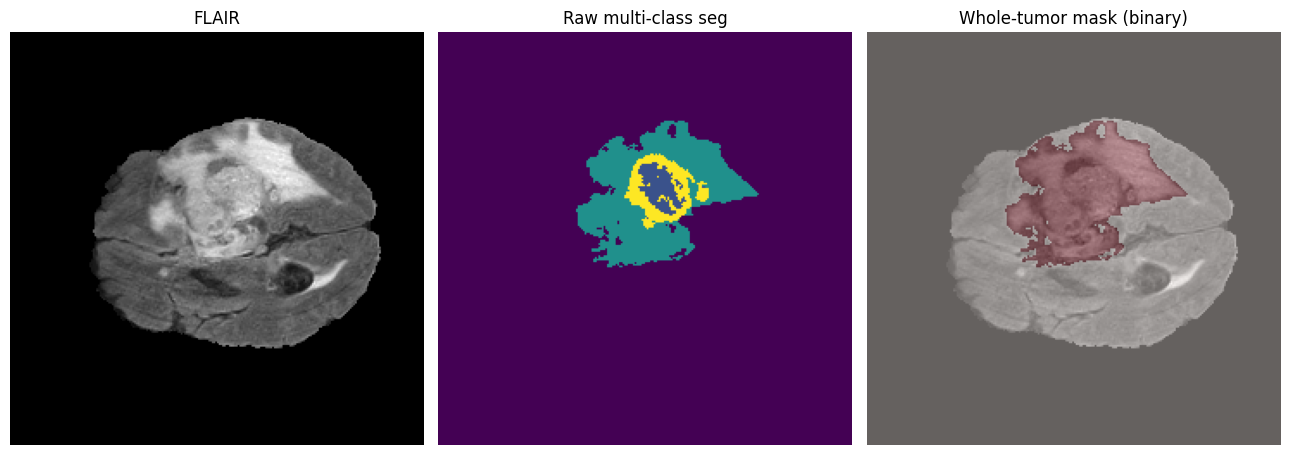

Case BraTS20_Training_001, slice 70: tumor pixels = 5017 / 57600


In [18]:
sample_case = sorted([f.name for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()])[0]
cp = os.path.join(TRAIN_DATASET_PATH, sample_case)
flair = nib.load(os.path.join(cp, f'{sample_case}_flair.nii')).get_fdata()
seg   = nib.load(os.path.join(cp, f'{sample_case}_seg.nii')).get_fdata()

s = 70  # slice index
wt = (seg[:, :, s] > 0).astype(np.uint8)  # whole tumor = labels 1 + 2 + 4

fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].imshow(flair[:, :, s], cmap='gray'); ax[0].set_title('FLAIR'); ax[0].axis('off')
ax[1].imshow(seg[:, :, s]);               ax[1].set_title('Raw multi-class seg'); ax[1].axis('off')
ax[2].imshow(flair[:, :, s], cmap='gray')
ax[2].imshow(wt, cmap='Reds', alpha=0.4); ax[2].set_title('Whole-tumor mask (binary)'); ax[2].axis('off')
plt.tight_layout(); plt.show()

print(f"Case {sample_case}, slice {s}: tumor pixels = {wt.sum()} / {wt.size}")

# 4. Split the Dataset

The split is over whole **patients** (case IDs), before slicing, with fixed `random_state` — so it is
reproducible and no patient's slices leak across train/val/test.

In [19]:
# ---------------------------------------------------------------------------
# DATASET-SIZE ABLATION: use the SAME 100 patients (cases 001-100), with a
# FIXED held-out test set (8) and validation set (12). Two training points:
#
#   * 59-patient setting -> 39 train, 12 val, 8 test
#   * 100-patient setting ->  80 train, 12 val, 8 test  (same val/test patients)
#
# Only the number of TRAINING patients changes; val/test are identical in both,
# so any change in test Dice is due to training-set size alone. The held-out
# patients are within cases 001-059, so they exist in both settings.
# ---------------------------------------------------------------------------
import hashlib

MAX_PATIENTS = 100  # cap the pool to the first 100 cases (001-100)

FIXED_VAL_IDS = [
    'BraTS20_Training_001', 'BraTS20_Training_004', 'BraTS20_Training_006',
    'BraTS20_Training_013', 'BraTS20_Training_014', 'BraTS20_Training_026',
    'BraTS20_Training_035', 'BraTS20_Training_046', 'BraTS20_Training_048',
    'BraTS20_Training_050', 'BraTS20_Training_054', 'BraTS20_Training_058',
]
FIXED_TEST_IDS = [
    'BraTS20_Training_011', 'BraTS20_Training_015', 'BraTS20_Training_016',
    'BraTS20_Training_030', 'BraTS20_Training_041', 'BraTS20_Training_044',
    'BraTS20_Training_057', 'BraTS20_Training_059',
]

# All case folders, sorted, then capped to the first MAX_PATIENTS (001-100).
all_ids = sorted(
    f.path[f.path.rfind('/') + 1:]
    for f in os.scandir(TRAIN_DATASET_PATH) if f.is_dir()
)[:MAX_PATIENTS]

held_out = set(FIXED_VAL_IDS) | set(FIXED_TEST_IDS)
missing = held_out - set(all_ids)
assert not missing, f"Held-out patients missing: {sorted(missing)}"

val_ids  = [i for i in all_ids if i in set(FIXED_VAL_IDS)]
test_ids = [i for i in all_ids if i in set(FIXED_TEST_IDS)]
# Full training pool = the 100 minus the 20 held out = 80 patients (sorted).
full_train_pool = [i for i in all_ids if i not in held_out]

# Two ablation points: 39 (the 59-patient setting) and 80 (the 100-patient setting).
TRAIN_SIZES = [39, 80]
TRAIN_SIZES = [n for n in TRAIN_SIZES if n <= len(full_train_pool)]

def _fingerprint(ids):
    return hashlib.md5(','.join(sorted(ids)).encode()).hexdigest()[:10]

print(f"Patients used (capped)   : {len(all_ids)}  (cases 001-{MAX_PATIENTS:03d})")
print(f"Full training pool       : {len(full_train_pool)}")
print(f"Validation (fixed)       : {len(val_ids)}  fp={_fingerprint(val_ids)}  (expect 01620d43a6)")
print(f"Test       (fixed)       : {len(test_ids)}  fp={_fingerprint(test_ids)}  (expect 90bcd58530)")
print(f"Ablation train sizes     : {TRAIN_SIZES}  (39 = 59-patient setting, 80 = 100-patient setting)")
print(f"Test IDs                 : {sorted(test_ids)}")


Patients used (capped)   : 100  (cases 001-100)
Full training pool       : 80
Validation (fixed)       : 12  fp=01620d43a6  (expect 01620d43a6)
Test       (fixed)       : 8  fp=90bcd58530  (expect 90bcd58530)
Ablation train sizes     : [39, 80]  (39 = 59-patient setting, 80 = 100-patient setting)
Test IDs                 : ['BraTS20_Training_011', 'BraTS20_Training_015', 'BraTS20_Training_016', 'BraTS20_Training_030', 'BraTS20_Training_041', 'BraTS20_Training_044', 'BraTS20_Training_057', 'BraTS20_Training_059']


# 5. Preload Data into RAM (binary masks)

Each MRI volume is read from disk **once**, sliced, resized, and normalized, then cached in memory.
This removes the redundant disk I/O that otherwise dominates training time. The whole-tumor mask is
built here as `seg > 0`.

In [20]:
def preload_cases(list_IDs, desc=""):
    """Load each case once. Returns X (N,2,H,W) float32 and Y (N,H,W) uint8 binary WT masks."""
    X_all, Y_all = [], []
    for k, case_id in enumerate(list_IDs):
        cp = os.path.join(TRAIN_DATASET_PATH, case_id)
        flair = nib.load(os.path.join(cp, f'{case_id}_flair.nii')).get_fdata()
        t1ce  = nib.load(os.path.join(cp, f'{case_id}_t1ce.nii')).get_fdata()
        seg   = nib.load(os.path.join(cp, f'{case_id}_seg.nii')).get_fdata()
        for j in range(VOLUME_SLICES):
            sp = j + VOLUME_START_AT
            x = np.zeros((IMG_SIZE, IMG_SIZE, 2), dtype=np.float32)
            x[:, :, 0] = cv2.resize(flair[:, :, sp], (IMG_SIZE, IMG_SIZE))
            x[:, :, 1] = cv2.resize(t1ce[:, :, sp],  (IMG_SIZE, IMG_SIZE))
            for c in range(2):
                ch = x[:, :, c]; mn, mx = ch.min(), ch.max()
                if mx > mn:
                    x[:, :, c] = (ch - mn) / (mx - mn)
            wt = (seg[:, :, sp] > 0).astype(np.uint8)
            wt = cv2.resize(wt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
            X_all.append(x.transpose(2, 0, 1))
            Y_all.append(wt)
        print(f"  {desc}: {k + 1}/{len(list_IDs)} cases loaded", end="\r")
    print()
    return np.stack(X_all), np.stack(Y_all)


class BinaryBrainDataset(Dataset):
    """Serves preloaded in-RAM slices for binary whole-tumor segmentation."""
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])
        y = torch.from_numpy(self.Y[idx]).unsqueeze(0).float()
        return x, y


# Preload ONLY the FIXED validation and test sets here (they never change across
# the ablation). Each training pool is preloaded inside the experiment loop below.
print("Preloading FIXED validation + test sets into RAM...")
Xva, Yva = preload_cases(val_ids,  "val")
Xte, Yte = preload_cases(test_ids, "test")
valid_dataset = BinaryBrainDataset(Xva, Yva)
test_dataset  = BinaryBrainDataset(Xte, Yte)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
print(f"Val slices: {len(Xva)} | Test slices: {len(Xte)}")
print(f"Fixed val+test RAM: {(Xva.nbytes + Xte.nbytes) / 1e9:.2f} GB")


Preloading FIXED validation + test sets into RAM...
  val: 12/12 cases loaded
  test: 8/8 cases loaded
Val slices: 1200 | Test slices: 800
Fixed val+test RAM: 0.26 GB


# 6. Loss Function and Evaluation Metrics

**Loss:** binary cross-entropy + soft Dice. BCE alone is dominated by the large non-tumor area, so the
Dice term directly optimizes overlap on the tumor.

**Metrics (binary, thresholded at 0.5):** Dice, sensitivity (recall), specificity, precision.

*Note:* specificity will sit very high (~0.99) because non-tumor pixels dominate every slice — Dice and
sensitivity carry the real signal for this task.

In [21]:
class DiceBCELoss(nn.Module):
    """Combined BCE-with-logits + soft Dice loss for single-channel binary masks."""
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

    def forward(self, logits, target):
        # logits, target: (B, 1, H, W); target in {0,1}
        bce_loss = self.bce(logits, target)
        probs = torch.sigmoid(logits)
        p = probs.reshape(-1)
        t = target.reshape(-1)
        inter = (p * t).sum()
        dice = (2 * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)
        return self.bce_weight * bce_loss + self.dice_weight * (1 - dice)


def _binarize(y_pred, thr=0.5):
    return (y_pred > thr).float()

def dice_coef(y_true, y_pred, smooth=1e-6):
    """Hard Dice at threshold 0.5. y_pred = sigmoid probabilities."""
    p = _binarize(y_pred).reshape(-1)
    t = y_true.reshape(-1)
    inter = (p * t).sum()
    return (2 * inter + smooth) / (p.sum() + t.sum() + smooth)

def sensitivity(y_true, y_pred, eps=1e-7):
    """Recall = TP / (TP + FN)."""
    p = _binarize(y_pred); t = y_true
    tp = (p * t).sum()
    fn = ((1 - p) * t).sum()
    return tp / (tp + fn + eps)

def specificity(y_true, y_pred, eps=1e-7):
    """TN / (TN + FP)."""
    p = _binarize(y_pred); t = y_true
    tn = ((1 - p) * (1 - t)).sum()
    fp = (p * (1 - t)).sum()
    return tn / (tn + fp + eps)

def precision(y_true, y_pred, eps=1e-7):
    """TP / (TP + FP)."""
    p = _binarize(y_pred); t = y_true
    tp = (p * t).sum()
    fp = (p * (1 - t)).sum()
    return tp / (tp + fp + eps)

def compute_all_metrics(y_true, y_pred):
    """y_pred = sigmoid probabilities (B,1,H,W)."""
    return {
        'dice_coef':   dice_coef(y_true, y_pred).item(),
        'precision':   precision(y_true, y_pred).item(),
        'sensitivity': sensitivity(y_true, y_pred).item(),
        'specificity': specificity(y_true, y_pred).item(),
    }

# 7. The U-Net Model (single-channel output)

A standard U-Net encoder–decoder with BatchNorm in every convolutional block. For binary segmentation
it has a **single** output channel; the network returns raw logits, and sigmoid is applied in the loss
and at inference.

In [22]:
class UNet(nn.Module):
    """2D U-Net with BatchNorm. Output: (B, 1, H, W) raw logits for binary segmentation."""
    def __init__(self, in_channels=2, num_classes=1, dropout=0.5):
        super().__init__()

        def CBR(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            )

        self.enc1 = CBR(in_channels, 32)
        self.enc2 = CBR(32, 64)
        self.enc3 = CBR(64, 128)
        self.enc4 = CBR(128, 256)
        self.pool = nn.MaxPool2d(2, 2)

        self.bottleneck = CBR(256, 512)
        self.dropout = nn.Dropout2d(p=dropout)

        self.up6 = nn.ConvTranspose2d(512, 256, 2, stride=2); self.dec6 = CBR(512, 256)
        self.up7 = nn.ConvTranspose2d(256, 128, 2, stride=2); self.dec7 = CBR(256, 128)
        self.up8 = nn.ConvTranspose2d(128, 64,  2, stride=2); self.dec8 = CBR(128, 64)
        self.up9 = nn.ConvTranspose2d(64,  32,  2, stride=2); self.dec9 = CBR(64,  32)

        self.out_conv = nn.Conv2d(32, num_classes, 1)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))
        c4 = self.enc4(self.pool(c3))
        bn = self.dropout(self.bottleneck(self.pool(c4)))
        d6 = self.dec6(torch.cat([c4, self.up6(bn)], 1))
        d7 = self.dec7(torch.cat([c3, self.up7(d6)], 1))
        d8 = self.dec8(torch.cat([c2, self.up8(d7)], 1))
        d9 = self.dec9(torch.cat([c1, self.up9(d8)], 1))
        return self.out_conv(d9)  # raw logits

# 8. Build the Model

In [23]:
model = UNet(in_channels=2, num_classes=1).to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

criterion = DiceBCELoss(bce_weight=0.5, dice_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=3, min_lr=1e-6)

history = {k: [] for k in [
    'train_loss', 'val_loss', 'train_accuracy', 'val_accuracy',
    'train_dice_coef', 'val_dice_coef', 'train_precision', 'val_precision',
    'train_sensitivity', 'val_sensitivity', 'train_specificity', 'val_specificity',
    'learning_rate',
]}

def log_to_csv(epoch, train_metrics, val_metrics, filepath='training.log'):
    file_exists = os.path.isfile(filepath)
    with open(filepath, 'a', newline='') as f:
        fieldnames = (['epoch', 'lr']
                      + [f'train_{k}' for k in train_metrics]
                      + [f'val_{k}' for k in val_metrics])
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        row = {'epoch': epoch, 'lr': optimizer.param_groups[0]['lr']}
        row.update({f'train_{k}': v for k, v in train_metrics.items()})
        row.update({f'val_{k}': v for k, v in val_metrics.items()})
        writer.writerow(row)

Trainable parameters: 7,762,753


# 9. Training and Validation Helpers

In [24]:
def run_epoch(model, loader, criterion, optimizer, device, train, scaler=None):
    model.train() if train else model.eval()
    running_loss = 0.0
    sums = {'dice_coef': 0.0, 'precision': 0.0, 'sensitivity': 0.0, 'specificity': 0.0, 'accuracy': 0.0}
    n = 0
    use_amp = scaler is not None

    torch.set_grad_enabled(train)
    for X, y_true in loader:
        X, y_true = X.to(device), y_true.to(device)
        if train:
            optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(X)
            loss = criterion(logits, y_true)
        if train:
            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        running_loss += loss.item()
        with torch.no_grad():
            probs = torch.sigmoid(logits.float())
            acc = (_binarize(probs) == y_true).float().mean().item()
            m = compute_all_metrics(y_true, probs)
            for k in ['dice_coef', 'precision', 'sensitivity', 'specificity']:
                sums[k] += m[k]
            sums['accuracy'] += acc
        n += 1
    torch.set_grad_enabled(True)

    avg_metrics = {k: v / max(n, 1) for k, v in sums.items()}
    return running_loss / max(n, 1), avg_metrics


def evaluate_model(model, loader, device):
    model.eval()
    sums = {'dice_coef': 0.0, 'precision': 0.0, 'sensitivity': 0.0, 'specificity': 0.0}
    n = 0
    with torch.no_grad():
        for X, y_true in loader:
            X, y_true = X.to(device), y_true.to(device)
            with torch.amp.autocast('cuda'):
                probs = torch.sigmoid(model(X).float())
            m = compute_all_metrics(y_true, probs)
            for k in sums:
                sums[k] += m[k]
            n += 1
    return {k: v / max(n, 1) for k, v in sums.items()}


# 10. Train and Save the Model

In [25]:
import copy, gc

# ---------------------------------------------------------------------------
# EXPERIMENT RUNNER (Task 1, binary WT) -- faster: AMP + cuDNN benchmark +
# 2-GPU DataParallel + early stopping + batch size 64. Trains a fresh model per
# training-pool size and evaluates the best checkpoint on the FIXED test set.
# These speedups do not change the experiment design.
# ---------------------------------------------------------------------------
num_epochs = 30          # upper bound; early stopping usually ends sooner
EARLY_STOP_PATIENCE = 6
BATCH = 64               # larger batch -> fewer steps/epoch (was 32)

torch.backends.cudnn.benchmark = True
NUM_GPUS = torch.cuda.device_count()
print(f"Visible GPUs: {NUM_GPUS}")

def load_model(model, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    return model

def run_experiment(n_train):
    tag = f"{n_train}"
    train_subset = full_train_pool[:n_train]
    print("\n" + "#" * 60)
    print(f"# TASK 1 EXPERIMENT: {n_train} training patients "
          f"(val={len(val_ids)} fixed, test={len(test_ids)} fixed)")
    print("#" * 60)

    Xtr, Ytr = preload_cases(train_subset, f"train[{n_train}]")
    train_loader = DataLoader(BinaryBrainDataset(Xtr, Ytr), batch_size=BATCH,
                              shuffle=True, num_workers=0, pin_memory=True)
    print(f"Train slices: {len(Xtr)}  (~{Xtr.nbytes/1e9:.2f} GB)")

    base_model = UNet(in_channels=2, num_classes=1).to(device)
    model = nn.DataParallel(base_model) if NUM_GPUS > 1 else base_model
    criterion = DiceBCELoss(bce_weight=0.5, dice_weight=0.5)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.2, patience=3, min_lr=1e-6)
    scaler = torch.amp.GradScaler('cuda')

    hist = {k: [] for k in [
        'train_loss','val_loss','train_accuracy','val_accuracy',
        'train_dice_coef','val_dice_coef','val_precision','val_sensitivity',
        'val_specificity','learning_rate']}

    best_val_dice = -1.0
    best_path = f"best_model_task1_{tag}.pth"
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        train_loss, train_metrics = run_epoch(model, train_loader, criterion, optimizer, device, train=True,  scaler=scaler)
        val_loss,   val_metrics   = run_epoch(model, valid_loader, criterion, optimizer, device, train=False)
        scheduler.step(val_metrics['dice_coef'])

        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
        hist['train_accuracy'].append(train_metrics['accuracy'])
        hist['val_accuracy'].append(val_metrics['accuracy'])
        hist['train_dice_coef'].append(train_metrics['dice_coef'])
        hist['val_dice_coef'].append(val_metrics['dice_coef'])
        hist['val_precision'].append(val_metrics['precision'])
        hist['val_sensitivity'].append(val_metrics['sensitivity'])
        hist['val_specificity'].append(val_metrics['specificity'])
        hist['learning_rate'].append(optimizer.param_groups[0]['lr'])

        # Print every epoch, one by one.
        print(f"  epoch {epoch+1:2d}/{num_epochs} | "
              f"train loss {train_loss:.4f} val loss {val_loss:.4f} | "
              f"val Dice {val_metrics['dice_coef']:.4f} | "
              f"sens {val_metrics['sensitivity']:.4f} spec {val_metrics['specificity']:.4f}")

        if val_metrics['dice_coef'] > best_val_dice:
            best_val_dice = val_metrics['dice_coef']
            epochs_no_improve = 0
            state = (model.module if isinstance(model, nn.DataParallel) else model).state_dict()
            torch.save({'epoch': epoch + 1, 'model_state_dict': state}, best_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOP_PATIENCE:
                print(f"  early stop at epoch {epoch+1}")
                break

    best_model = load_model(UNet(in_channels=2, num_classes=1).to(device), best_path)
    test_metrics = evaluate_model(best_model, test_loader, device)
    print(f"  >> {n_train} patients | TEST Dice {test_metrics['dice_coef']:.4f} | "
          f"sens {test_metrics['sensitivity']:.4f} spec {test_metrics['specificity']:.4f} "
          f"prec {test_metrics['precision']:.4f}")

    del Xtr, Ytr, train_loader, model, base_model
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    return {'n_train': n_train, 'test_metrics': test_metrics,
            'best_val_dice': best_val_dice, 'history': hist}

results = {}
for n in TRAIN_SIZES:
    results[n] = run_experiment(n)

print("\nAll Task 1 experiments complete.")

largest = max(TRAIN_SIZES)
history = results[largest]['history']
best_model_path = f"best_model_task1_{largest}.pth"
model = load_model(UNet(in_channels=2, num_classes=1).to(device), best_model_path)
best_model = model
print(f"Globals set for qualitative viz: model = best {largest}-patient run.")


Visible GPUs: 2

############################################################
# TASK 1 EXPERIMENT: 39 training patients (val=12 fixed, test=8 fixed)
############################################################
  train[39]: 39/39 cases loaded
Train slices: 3900  (~0.51 GB)
  epoch  1/30 | train loss 0.2992 val loss 0.2968 | val Dice 0.5560 | sens 0.4484 spec 0.9990
  epoch  2/30 | train loss 0.0991 val loss 0.2425 | val Dice 0.6497 | sens 0.5217 spec 0.9992
  epoch  3/30 | train loss 0.0789 val loss 0.2363 | val Dice 0.6333 | sens 0.6235 spec 0.9966
  epoch  4/30 | train loss 0.0766 val loss 0.2305 | val Dice 0.6341 | sens 0.5586 spec 0.9982
  epoch  5/30 | train loss 0.0661 val loss 0.2681 | val Dice 0.6176 | sens 0.4266 spec 0.9998
  epoch  6/30 | train loss 0.0598 val loss 0.2139 | val Dice 0.6635 | sens 0.6471 spec 0.9967
  epoch  7/30 | train loss 0.0620 val loss 0.2336 | val Dice 0.6740 | sens 0.5210 spec 0.9994
  epoch  8/30 | train loss 0.0556 val loss 0.2416 | val Dice 0.6620 |

# 11. Training History

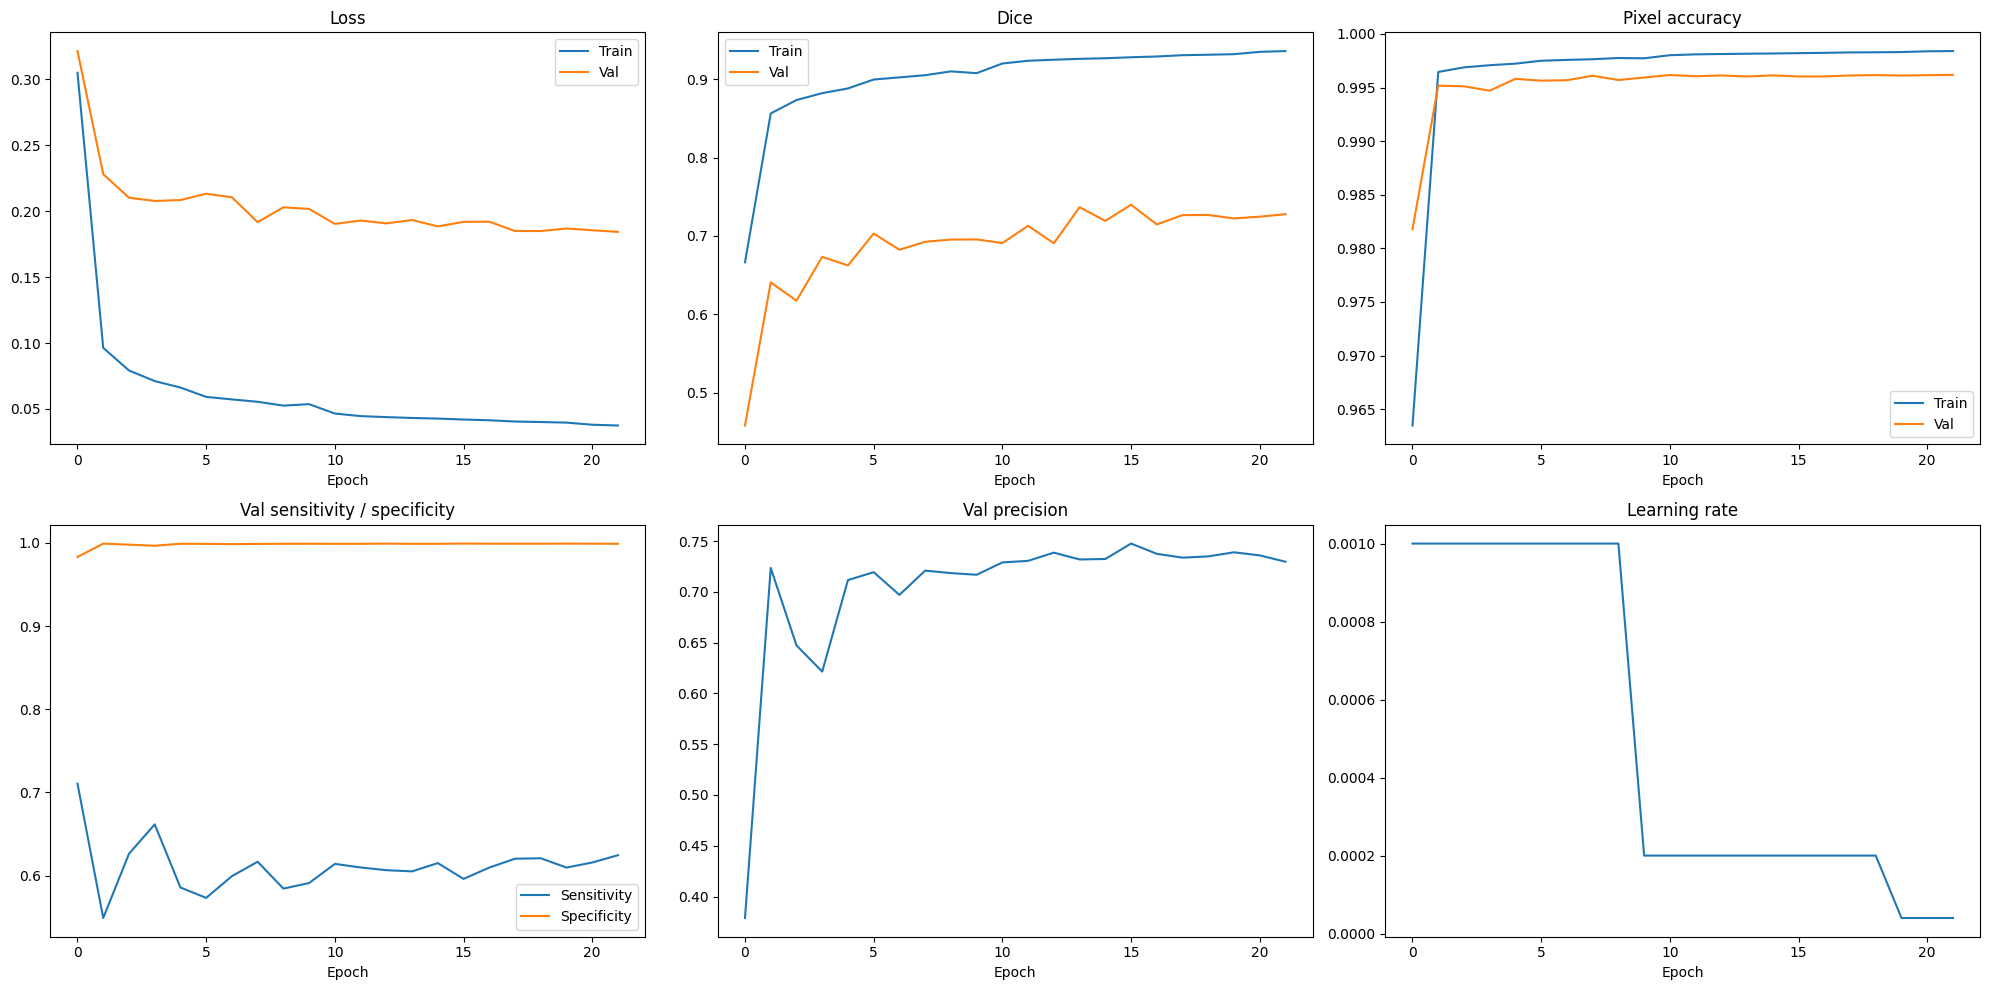

In [26]:
def plot_training_history(history):
    fig, ax = plt.subplots(2, 3, figsize=(20, 10))
    ax[0, 0].plot(history['train_loss'], label='Train'); ax[0, 0].plot(history['val_loss'], label='Val')
    ax[0, 0].set_title('Loss'); ax[0, 0].set_xlabel('Epoch'); ax[0, 0].legend()
    ax[0, 1].plot(history['train_dice_coef'], label='Train'); ax[0, 1].plot(history['val_dice_coef'], label='Val')
    ax[0, 1].set_title('Dice'); ax[0, 1].set_xlabel('Epoch'); ax[0, 1].legend()
    ax[0, 2].plot(history['train_accuracy'], label='Train'); ax[0, 2].plot(history['val_accuracy'], label='Val')
    ax[0, 2].set_title('Pixel accuracy'); ax[0, 2].set_xlabel('Epoch'); ax[0, 2].legend()
    ax[1, 0].plot(history['val_sensitivity'], label='Sensitivity'); ax[1, 0].plot(history['val_specificity'], label='Specificity')
    ax[1, 0].set_title('Val sensitivity / specificity'); ax[1, 0].set_xlabel('Epoch'); ax[1, 0].legend()
    ax[1, 1].plot(history['val_precision']); ax[1, 1].set_title('Val precision'); ax[1, 1].set_xlabel('Epoch')
    ax[1, 2].plot(history['learning_rate']); ax[1, 2].set_title('Learning rate'); ax[1, 2].set_xlabel('Epoch')
    plt.tight_layout(); plt.savefig('training_history_task1.png', dpi=150, bbox_inches='tight'); plt.show()

plot_training_history(history)

# 12. Load the Best Model

In [27]:
def load_model(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model

best_model = load_model(model, best_model_path)
val_metrics = evaluate_model(best_model, valid_loader, device)
print("Validation performance (best model):")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")

Validation performance (best model):
  dice_coef: 0.7399
  precision: 0.7476
  sensitivity: 0.5961
  specificity: 0.9991


# 13. Predict and Visualize Whole-Tumor Segmentations

In [28]:
def predictByPath(case, model, device):
    """Predict whole-tumor probability volume for one case. Returns (VOLUME_SLICES, H, W)."""
    path = os.path.join(TRAIN_DATASET_PATH, f'BraTS20_Training_{case}')
    flair = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()
    t1ce  = nib.load(os.path.join(path, f'BraTS20_Training_{case}_t1ce.nii')).get_fdata()

    X = np.zeros((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, 2), dtype=np.float32)
    for j in range(VOLUME_SLICES):
        sp = j + VOLUME_START_AT
        X[j, :, :, 0] = cv2.resize(flair[:, :, sp], (IMG_SIZE, IMG_SIZE))
        X[j, :, :, 1] = cv2.resize(t1ce[:, :, sp],  (IMG_SIZE, IMG_SIZE))
    # per-channel, per-slice normalization to match training
    for j in range(VOLUME_SLICES):
        for c in range(2):
            ch = X[j, :, :, c]; mn, mx = ch.min(), ch.max()
            if mx > mn:
                X[j, :, :, c] = (ch - mn) / (mx - mn)

    X_tensor = torch.from_numpy(X).permute(0, 3, 1, 2).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_tensor))      # (S, 1, H, W)
    return probs.cpu().squeeze(1).numpy()           # (S, H, W)

In [29]:
def showPredictsById(case, model, device, start_slice=60, thr=0.5):
    path = os.path.join(TRAIN_DATASET_PATH, f'BraTS20_Training_{case}')
    gt    = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
    flair = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()

    p = predictByPath(case, model, device)                 # (S, H, W) probabilities
    sp = start_slice + VOLUME_START_AT

    brain = cv2.resize(flair[:, :, sp], (IMG_SIZE, IMG_SIZE))
    gt_wt = cv2.resize((gt[:, :, sp] > 0).astype(np.uint8), (IMG_SIZE, IMG_SIZE),
                       interpolation=cv2.INTER_NEAREST)
    pred_wt = (p[start_slice] > thr).astype(np.uint8)

    fig, ax = plt.subplots(1, 4, figsize=(18, 5))
    ax[0].imshow(brain, cmap='gray'); ax[0].set_title('FLAIR'); ax[0].axis('off')
    ax[1].imshow(brain, cmap='gray'); ax[1].imshow(gt_wt, cmap='Reds', alpha=0.4)
    ax[1].set_title('Ground-truth WT'); ax[1].axis('off')
    ax[2].imshow(brain, cmap='gray'); ax[2].imshow(p[start_slice], cmap='Reds', alpha=0.5)
    ax[2].set_title('Predicted probability'); ax[2].axis('off')
    ax[3].imshow(brain, cmap='gray'); ax[3].imshow(pred_wt, cmap='Reds', alpha=0.4)
    ax[3].set_title(f'Predicted WT (>{thr})'); ax[3].axis('off')
    plt.suptitle(f'Case {case}, slice {start_slice}')
    plt.tight_layout(); plt.show()

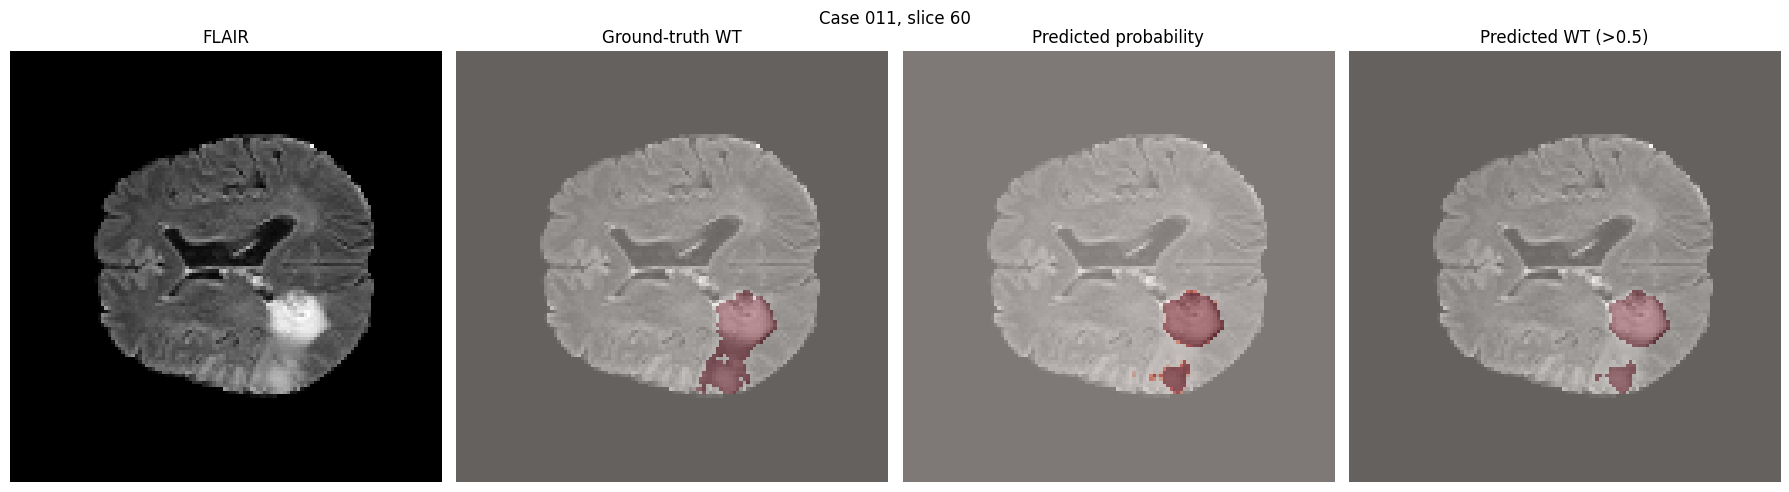

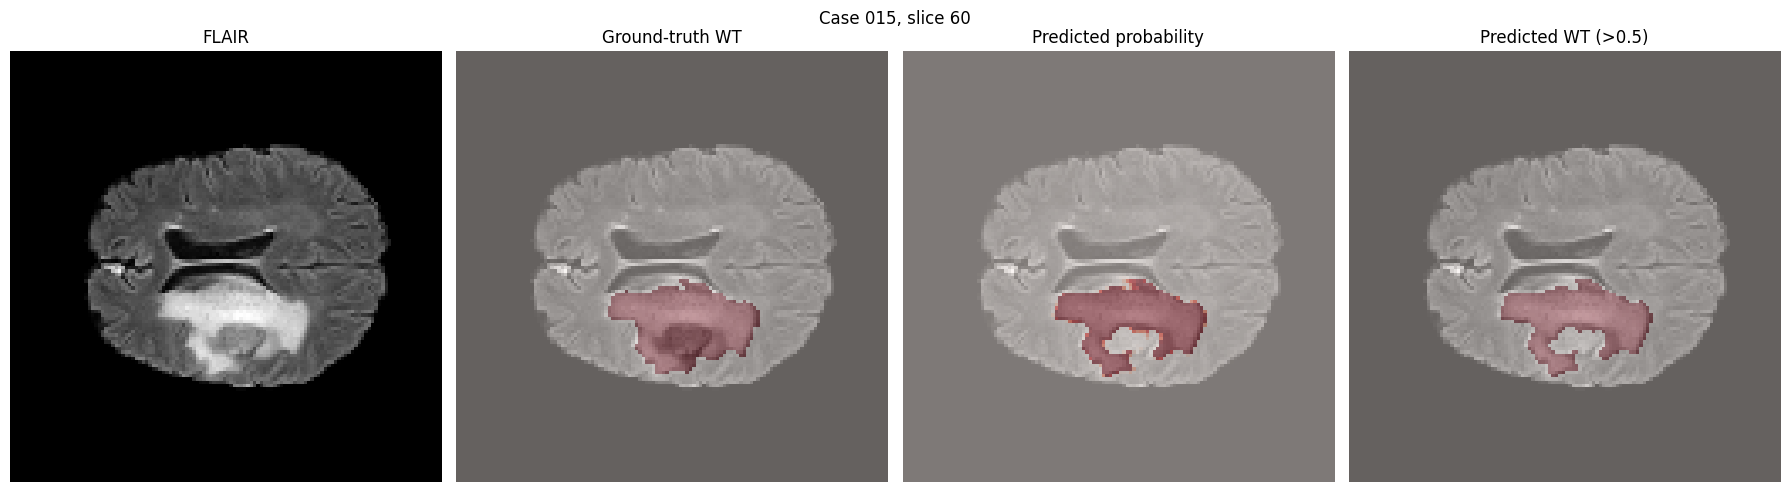

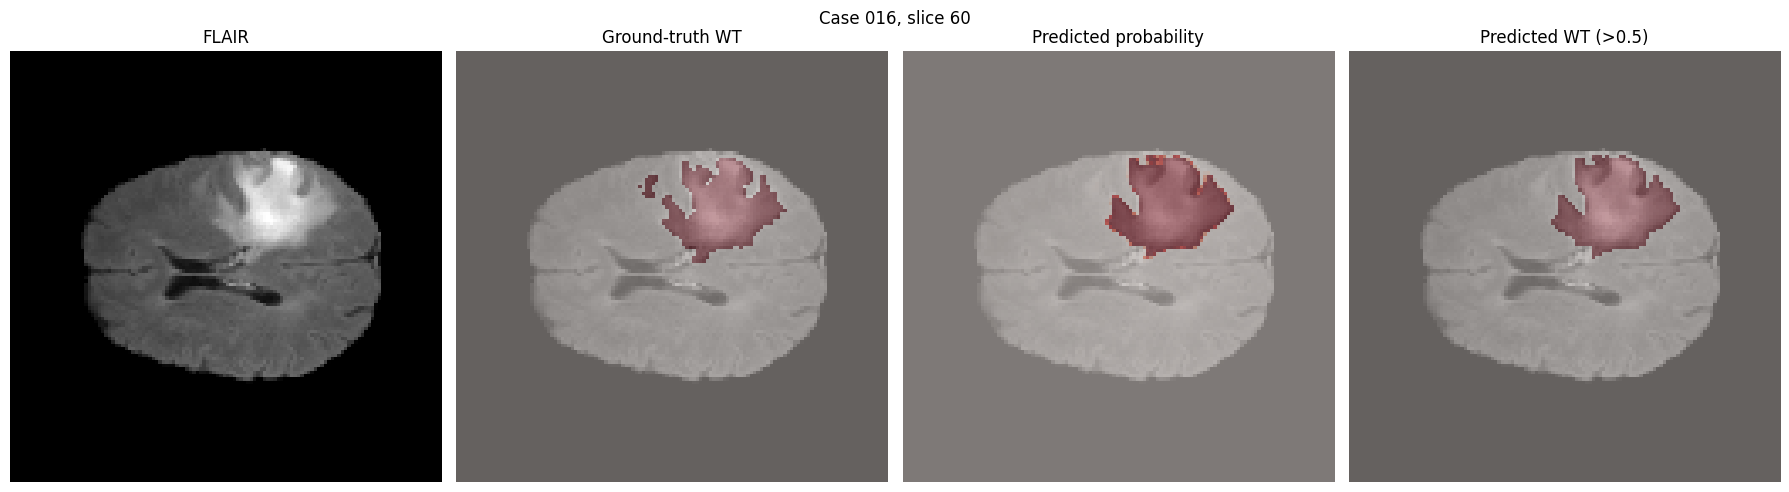

In [30]:
for cid in [test_ids[0][-3:], test_ids[1][-3:], test_ids[2][-3:]]:
    showPredictsById(case=cid, model=best_model, device=device)

# 14. Final Evaluation on the Test Set

TASK 1 (binary WT) test performance vs training-set size (fixed test set):
                WT Dice  Sensitivity  Specificity  Precision
Train patients                                              
39               0.6940       0.6185       0.9989     0.7466
80               0.7709       0.6514       0.9990     0.7960


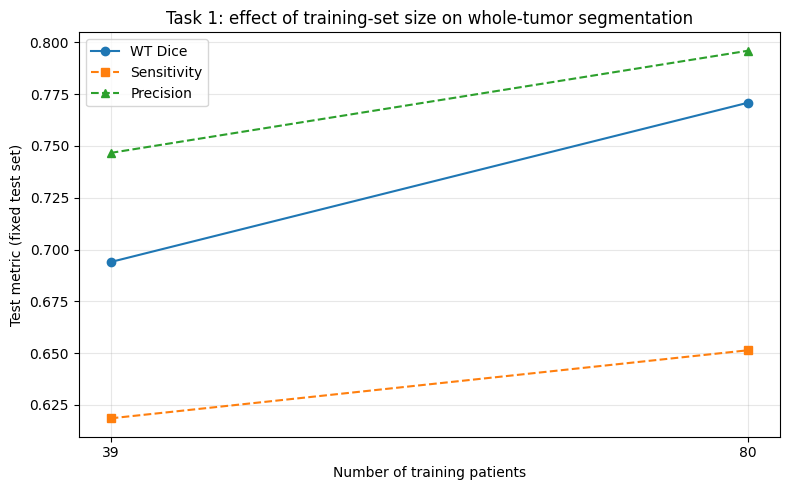

,WT Dice,Sensitivity,Specificity,Precision
Train patients,,,,
39,0.6940,0.6185,0.9989,0.7466
80,0.7709,0.6514,0.9990,0.7960


In [31]:
# ---------------------------------------------------------------------------
# RESULTS TABLE + TREND PLOT: test-set whole-tumor Dice vs. training-set size
# (same fixed 8-patient test set across all runs).
# ---------------------------------------------------------------------------
import pandas as pd

rows = []
for n in TRAIN_SIZES:
    m = results[n]['test_metrics']
    rows.append({
        'Train patients': n,
        'WT Dice':     round(m['dice_coef'], 4),
        'Sensitivity': round(m['sensitivity'], 4),
        'Specificity': round(m['specificity'], 4),
        'Precision':   round(m['precision'], 4),
    })
df = pd.DataFrame(rows).set_index('Train patients')
print("TASK 1 (binary WT) test performance vs training-set size (fixed test set):")
print(df.to_string())
df.to_csv('task1_ablation_results.csv')

sizes = TRAIN_SIZES
wt   = [results[n]['test_metrics']['dice_coef']   for n in sizes]
sens = [results[n]['test_metrics']['sensitivity'] for n in sizes]
prec = [results[n]['test_metrics']['precision']   for n in sizes]

plt.figure(figsize=(8, 5))
plt.plot(sizes, wt,   'o-', label='WT Dice')
plt.plot(sizes, sens, 's--', label='Sensitivity')
plt.plot(sizes, prec, '^--', label='Precision')
plt.xlabel('Number of training patients')
plt.ylabel('Test metric (fixed test set)')
plt.title('Task 1: effect of training-set size on whole-tumor segmentation')
plt.xticks(sizes)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('task1_ablation_trend.png', dpi=150, bbox_inches='tight')
plt.show()
df


# 15. Save Results & Figures to Disk (for download)

Everything written to `/kaggle/working/` can be downloaded after the run (right-hand
**Output** panel, or the **Output** tab of a committed version). This section saves the
Task 1 deliverables:

* `task1_results.json` / `task1_results.csv` — the test-set metrics (whole-tumor Dice,
  sensitivity, specificity, precision).
* `task1_metrics.png` — bar chart of those metrics.
* `task1_overlays.png` — qualitative FLAIR / ground-truth / prediction panels.

(The training-curve figure `training_history_task1.png` is already saved by
`plot_training_history` in Section 11.)

In [33]:
# --- Save the test-set metrics to JSON + CSV ---
# best_val_dice / test_metrics were LOCAL to run_experiment(); recover them
# from the in-memory experiment results for the largest (best) training run.
import json, csv, os

OUTDIR = "/kaggle/working"
os.makedirs(OUTDIR, exist_ok=True)

largest = max(TRAIN_SIZES)
best_val_dice = results[largest]["best_val_dice"]
test_metrics  = results[largest]["test_metrics"]

task1_results = {
    "task": "task1_binary_whole_tumor_segmentation",
    "n_train_patients": largest,
    "best_val_dice": float(best_val_dice),
    "test": {k: float(v) for k, v in test_metrics.items()},
}
with open(os.path.join(OUTDIR, "task1_results.json"), "w") as f:
    json.dump(task1_results, f, indent=2)

flat = {"best_val_dice": float(best_val_dice)}
flat.update({f"test_{k}": float(v) for k, v in test_metrics.items()})
with open(os.path.join(OUTDIR, "task1_results.csv"), "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(flat.keys()))
    w.writeheader()
    w.writerow(flat)

print("Saved task1_results.json and task1_results.csv")
print(json.dumps(task1_results, indent=2))

Saved task1_results.json and task1_results.csv
{
  "task": "task1_binary_whole_tumor_segmentation",
  "n_train_patients": 80,
  "best_val_dice": 0.7398328792593812,
  "test": {
    "dice_coef": 0.7708744468455316,
    "precision": 0.7959552335739136,
    "sensitivity": 0.6513804709911346,
    "specificity": 0.9989987826347351
  }
}


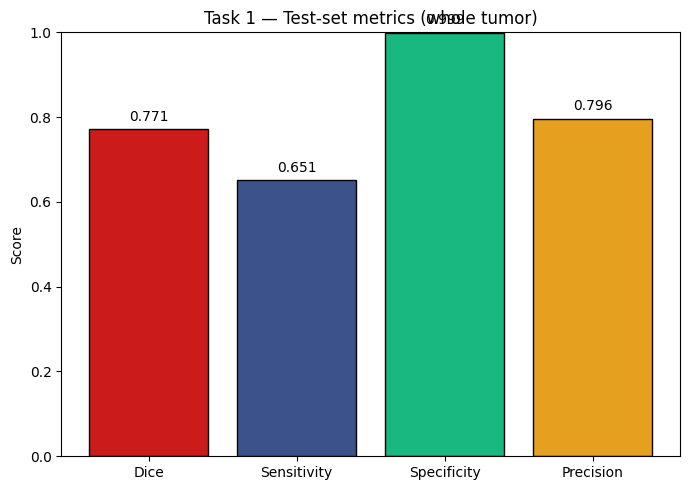

Saved task1_metrics.png


In [34]:
# --- Bar chart of the whole-tumor test metrics ---
import matplotlib.pyplot as plt

labels = ["Dice", "Sensitivity", "Specificity", "Precision"]
vals   = [test_metrics["dice_coef"], test_metrics["sensitivity"],
          test_metrics["specificity"], test_metrics["precision"]]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, vals, color=["#cc1b1b", "#3b528b", "#18b880", "#e6a020"], edgecolor="black")
ax.set_ylim(0, 1); ax.set_ylabel("Score")
ax.set_title("Task 1 — Test-set metrics (whole tumor)")
for r, v in zip(bars, vals):
    ax.text(r.get_x() + r.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("/kaggle/working/task1_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved task1_metrics.png")

### Qualitative overlay panels

For each chosen test slice we show, side by side, the **FLAIR input**, the **ground-truth**
whole-tumor mask, and the **model prediction** (sigmoid thresholded at 0.5), with the tumour
region shaded in red. Slices are picked deterministically and spread across the test set,
restricted to slices that actually contain tumour so the panels are informative rather than
mostly background.

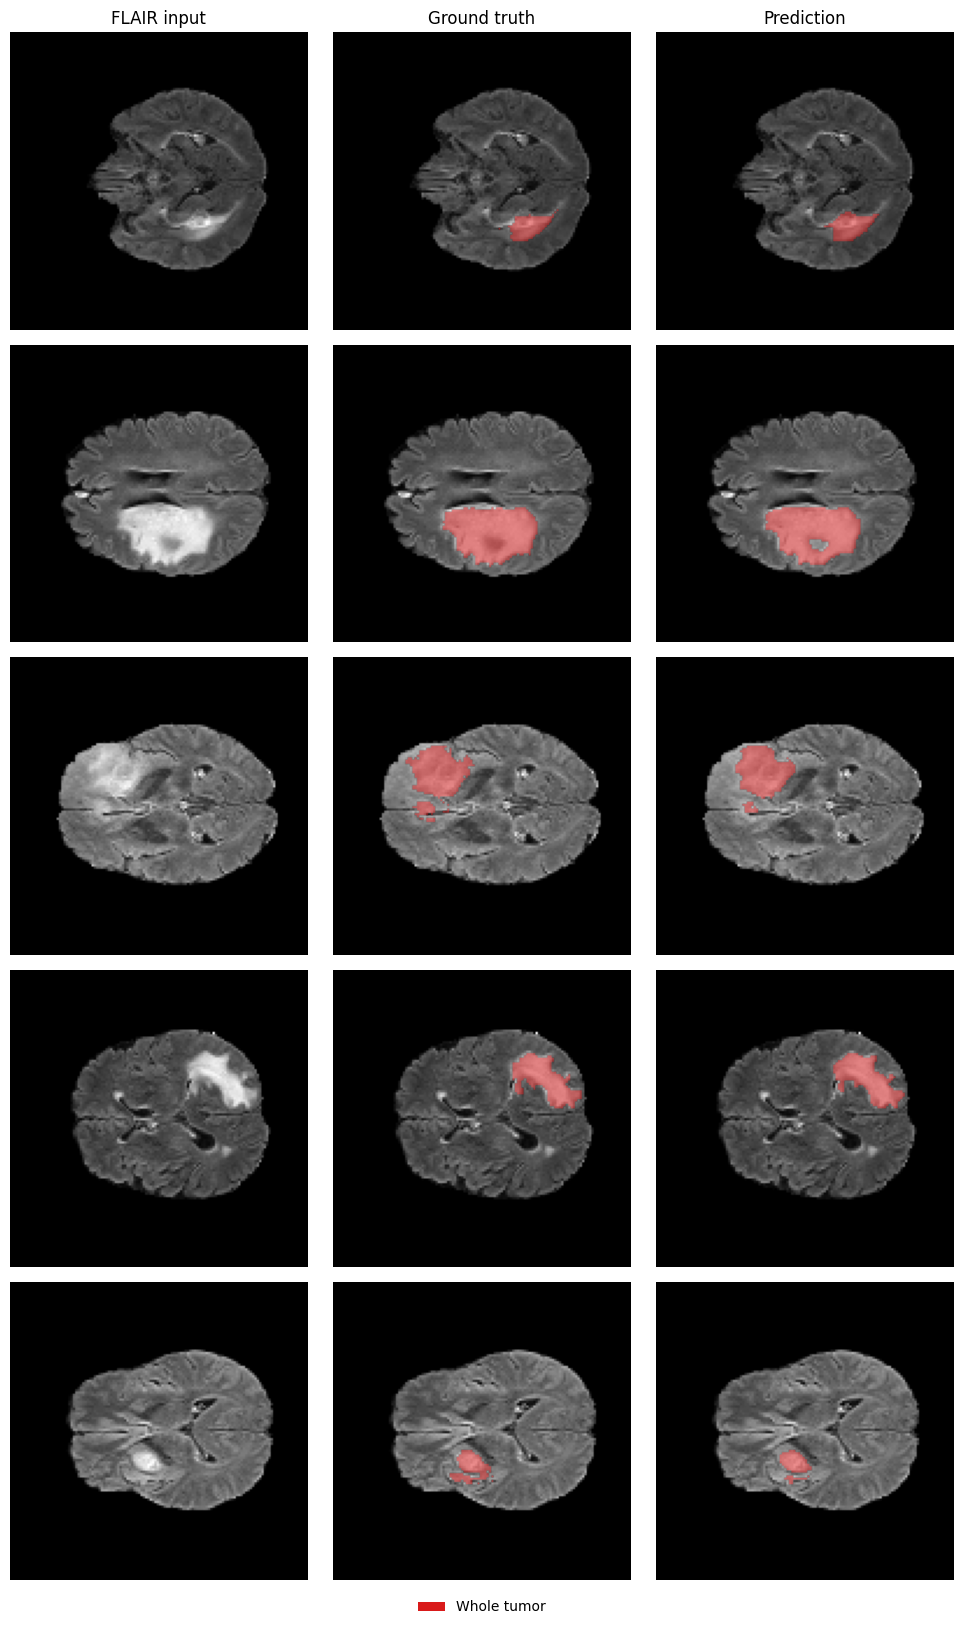

Saved task1_overlays.png  (slices [34, 166, 345, 453, 751])


In [35]:
# --- Qualitative FLAIR / Ground-truth / Prediction overlay panels ---
import numpy as np, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

TUMOR_COLOR = (0.85, 0.10, 0.10)  # red for the whole-tumor mask

def mask_to_rgba(mask, alpha=0.50):
    """(H,W) binary mask {0,1} -> (H,W,4) RGBA; background transparent."""
    h, w = mask.shape
    rgba = np.zeros((h, w, 4), dtype=np.float32)
    sel = mask == 1
    rgba[sel, 0], rgba[sel, 1], rgba[sel, 2], rgba[sel, 3] = (*TUMOR_COLOR, alpha)
    return rgba

# Pick a FIXED, reproducible set of tumour-containing test slices, spread across the set.
N_PANELS = 5
tumor_pixels = (Yte > 0).reshape(len(Yte), -1).sum(axis=1)
cand = np.where(tumor_pixels > 150)[0]
if len(cand) >= N_PANELS:
    chosen = cand[np.linspace(0, len(cand) - 1, N_PANELS).astype(int)]
else:
    chosen = np.argsort(tumor_pixels)[::-1][:N_PANELS]

# Predict on the chosen slices with the best model (single-channel sigmoid, threshold 0.5).
best_model.eval()
with torch.no_grad():
    xb = torch.from_numpy(Xte[chosen]).to(device)            # (N, 2, H, W)
    prob = torch.sigmoid(best_model(xb))                     # (N, 1, H, W)
    pred_mask = (prob > 0.5).float().squeeze(1).cpu().numpy()  # (N, H, W)

fig, axes = plt.subplots(N_PANELS, 3, figsize=(10, 3.2 * N_PANELS))
for row, idx in enumerate(chosen):
    flair = Xte[idx, 0]          # FLAIR channel
    for col in range(3):
        axes[row, col].imshow(flair, cmap="gray")
        axes[row, col].axis("off")
    axes[row, 1].imshow(mask_to_rgba(Yte[idx]))        # ground truth
    axes[row, 2].imshow(mask_to_rgba(pred_mask[row]))  # prediction

axes[0, 0].set_title("FLAIR input")
axes[0, 1].set_title("Ground truth")
axes[0, 2].set_title("Prediction")

fig.legend(handles=[Patch(facecolor=TUMOR_COLOR, label="Whole tumor")],
           loc="lower center", ncol=1, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("/kaggle/working/task1_overlays.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved task1_overlays.png  (slices {chosen.tolist()})")

# 15. Conclusion

This baseline performs **binary whole-tumor segmentation** (BraTS labels 1 + 2 + 4 vs. background) with
a BatchNorm U-Net trained on FLAIR + T1ce slices. It establishes a working end-to-end pipeline —
preprocessing, normalization, training, and evaluation — and gives a reference score on the easiest
BraTS target.

**Future work / next steps**
* **Multi-class sub-region segmentation:** split the single foreground class into the individual tumor
  sub-regions — necrotic/non-enhancing core, edema, and enhancing tumor. This is the harder, more
  clinically detailed problem and the natural follow-up to this baseline.
* Train on more cases (widen the unzip glob beyond the first ~60 patients).
* Add light data augmentation (flips, small rotations) for a modest robustness gain.